**Importing Libraries**

In [34]:
import pandas as pd                     #for data manipulation
import numpy as np                      #for data manipulation
import seaborn as sns                   #for visualization
from matplotlib import pyplot as plt    #for visualization

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt  #for time series analysis
from sklearn.linear_model import LinearRegression                               #for regression analysis

import warnings                                                                 #for ignoring warnings
warnings.filterwarnings("ignore")                                               #ignore warnings


**Import Dataset**

In [35]:
df = pd.read_csv(r"H:\Time Series Analysis\1. Time Series Forecasting\gold_monthly.csv")

In [37]:
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [38]:
df.tail()

,Date,Price
892,2024-11,2657.0
893,2025-01,2812.5
894,2025-02,2836.8
895,2025-03,3122.8
896,2025-04,3305.0


In [39]:
df.shape

(897, 2)

**EDA**

In [40]:
print(f"Date range of gold prices available from {df.loc[:,'Date'][0]} to {df.loc[:,'Date'][len(df)-1]}")

Date range of gold prices available from 1950-01 to 2025-04


In [41]:
date = pd.date_range(start = '1/1/1950', end = '4/1/2025', freq = 'M')
date

DatetimeIndex(['1950-01-31', '1950-02-28', '1950-03-31', '1950-04-30',
               '1950-05-31', '1950-06-30', '1950-07-31', '1950-08-31',
               '1950-09-30', '1950-10-31',
               ...
               '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30',
               '2024-10-31', '2024-11-30', '2024-12-31', '2025-01-31',
               '2025-02-28', '2025-03-31'],
              dtype='datetime64[ns]', length=903, freq='ME')

In [52]:
df.columns

Index(['Price', 'month'], dtype='object')

In [53]:
df['month'] = date  # Assign the 'date' values to the 'month' column
df = df.set_index('month')  # Set 'month' as the index
df.head()  # Display the first few rows
df.tail()  # Display the last few rows

,Price
month,
2024-05-31,2657.0
2024-06-30,2812.5
2024-07-31,2836.8
2024-08-31,3122.8
2024-09-30,3305.0


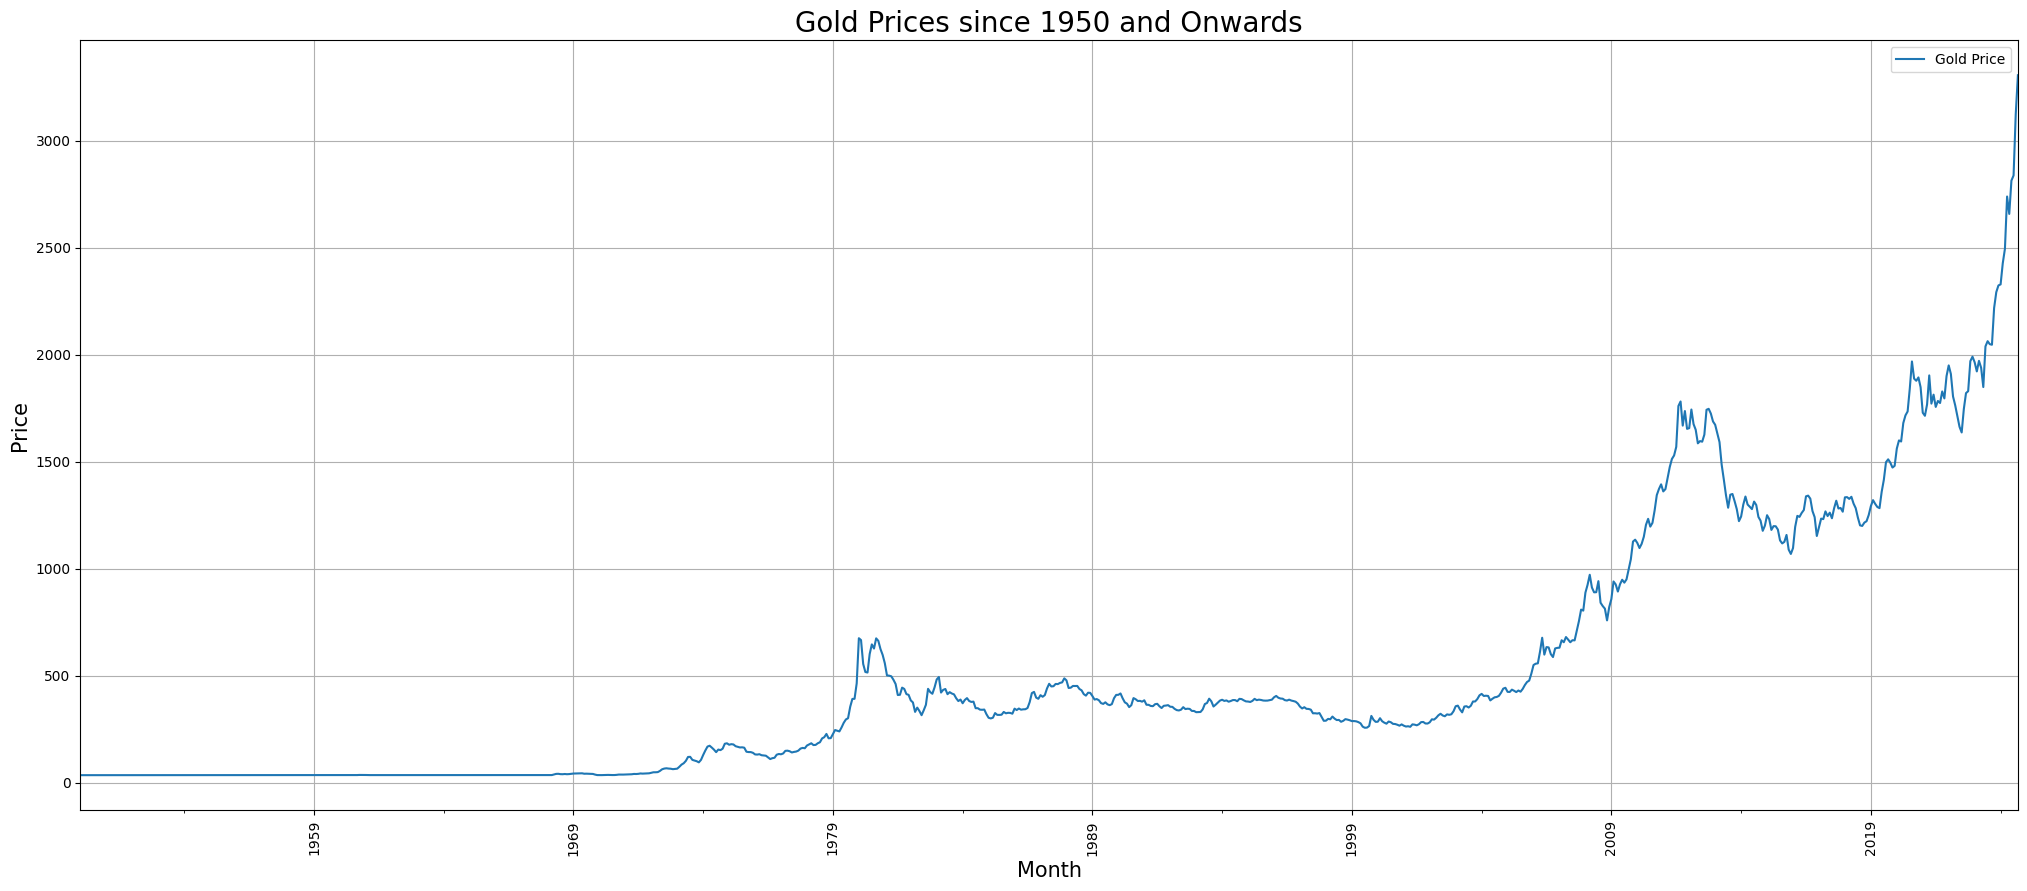

In [76]:
df.plot(figsize = (25,10))
plt.title('Gold Prices since 1950 and Onwards', fontsize = 20)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Price', fontsize = 15)
plt.xticks(rotation = 90, fontsize = 10)
plt.legend(['Gold Price'])
plt.grid()
plt.show()

In [59]:
round(df.describe(), 3) #summary statistics of the data

,Price
count,897.000
mean,507.251
std,584.679
min,34.490
25%,35.623
50%,340.217
75%,623.875
max,3305.000


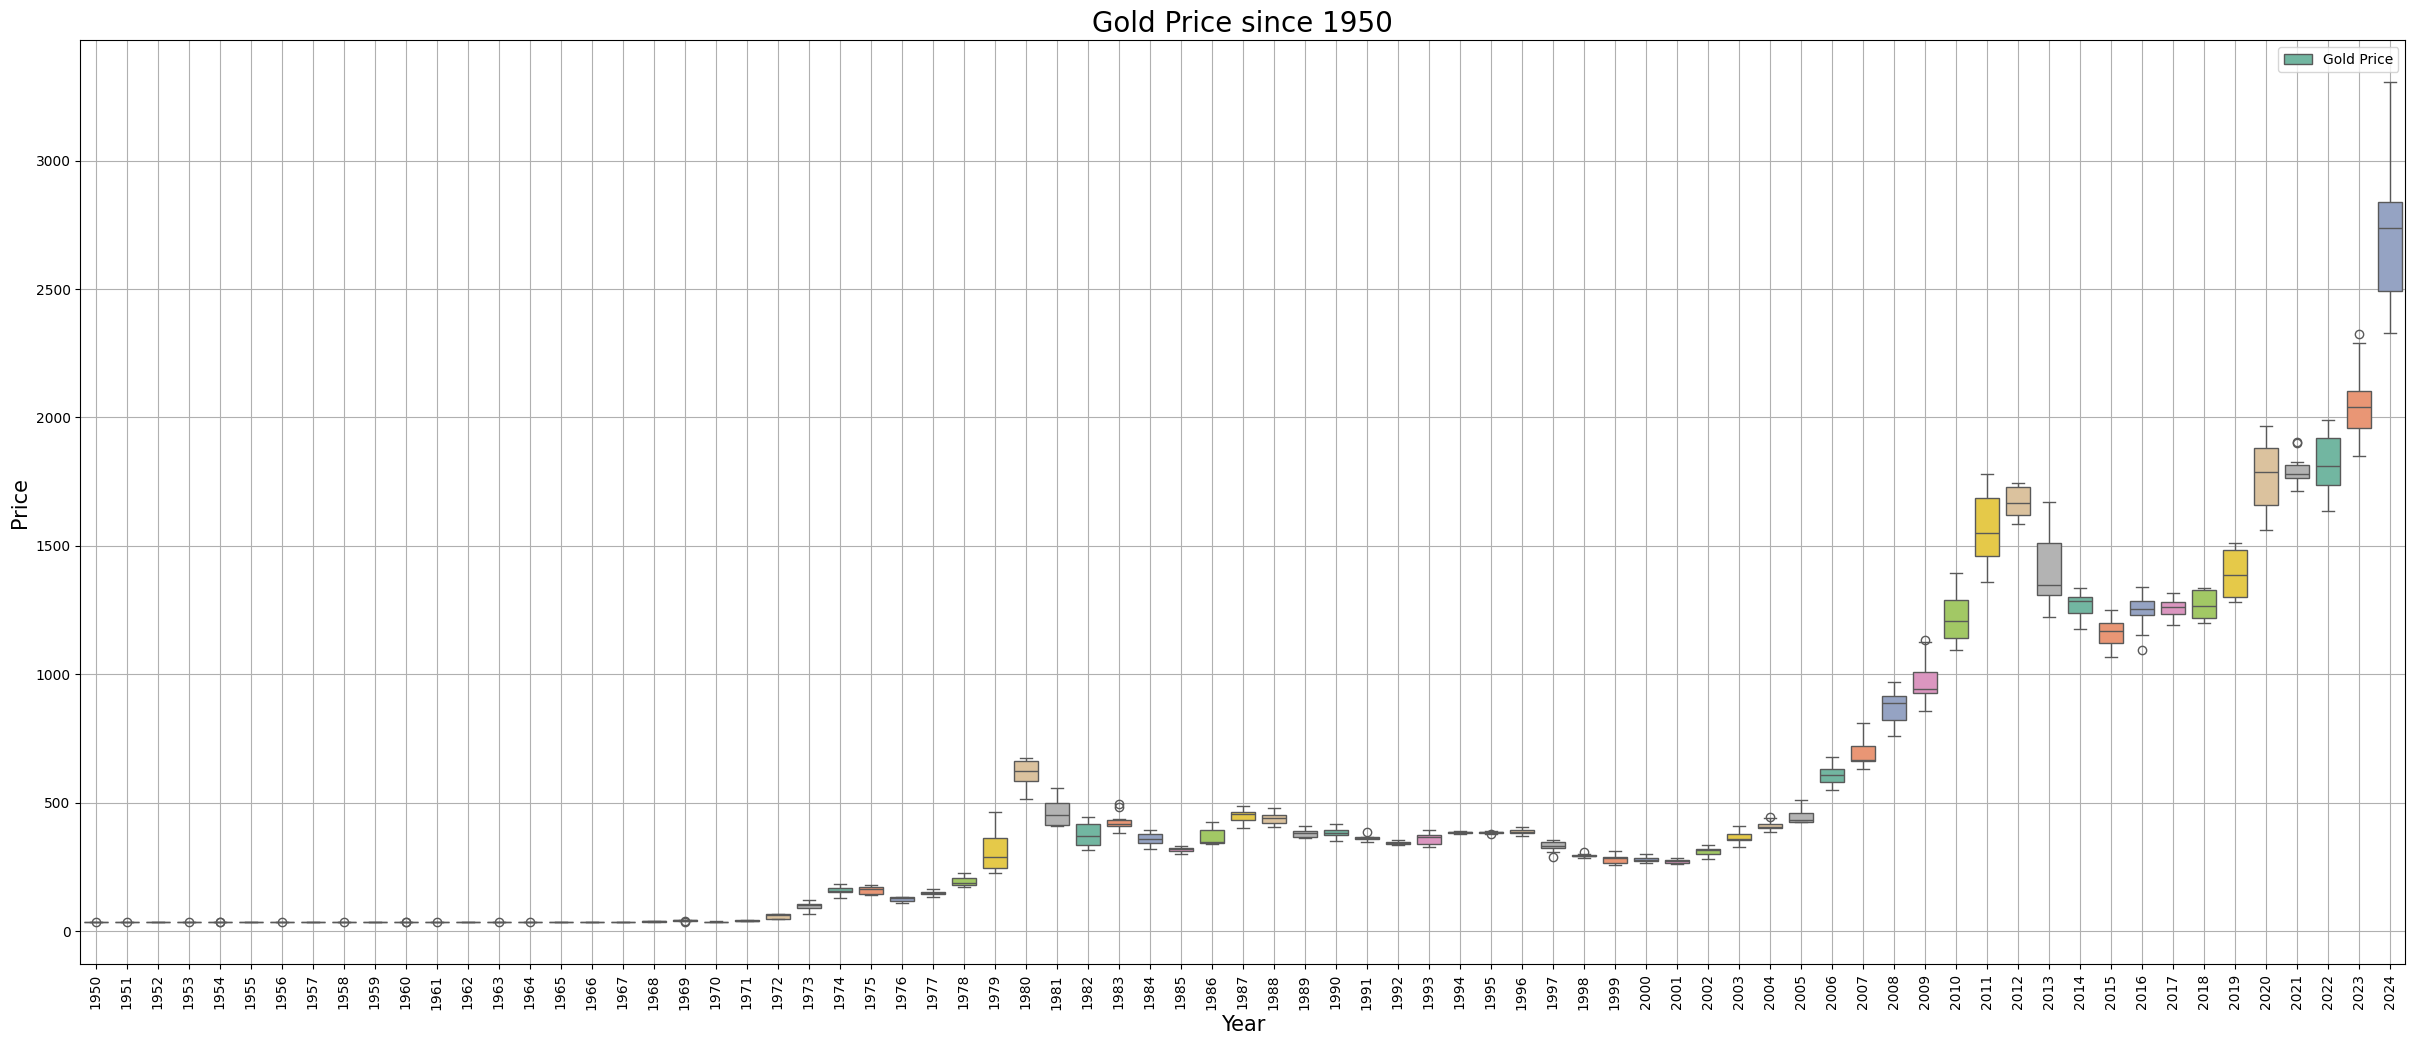

In [80]:
_, ax = plt.subplots(figsize = (30,12)) 
sns.boxplot(x = df.index.year, y = df.values[:,0], ax = ax, palette = 'Set2') #y = df.values[:,0] to get the first column of the dataframe x = df.index.year to get the year from the index ax = ax to specify the axis for the plot
plt.title('Gold Price since 1950', fontsize = 20)
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Price', fontsize = 15)
plt.xticks(rotation = 90, fontsize = 10)
plt.legend(['Gold Price'])
plt.grid()
plt.show();
#The boxplot shows that the gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

In [81]:
from statsmodels.graphics.tsaplots import month_plot

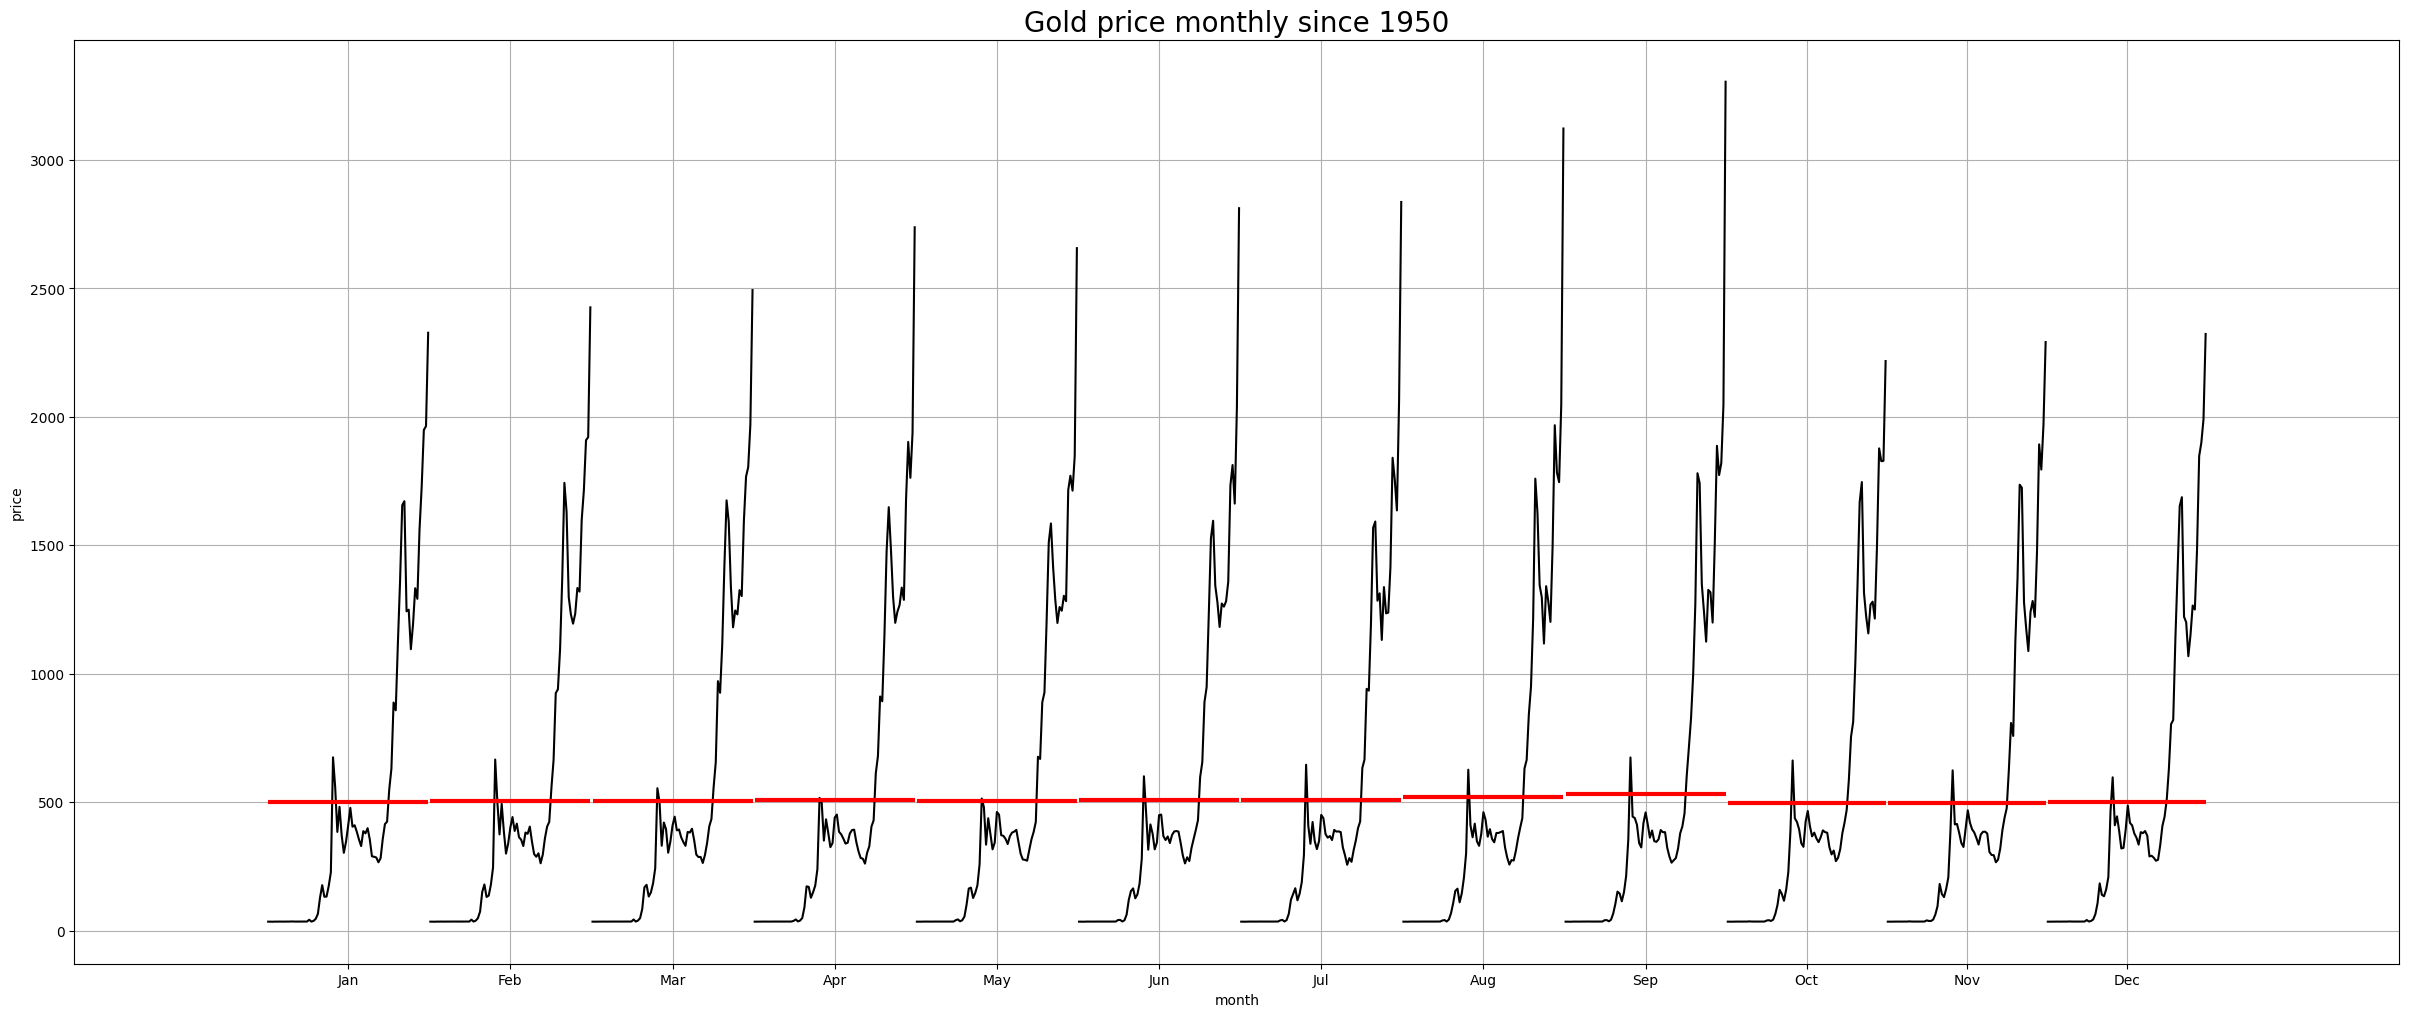

In [84]:
fig, ax = plt.subplots(figsize = (30,12)) #create a figure and axis for the plot
month_plot(df, ylabel = 'gold price', ax = ax) #plot the month plot for the gold prices
plt.title('Gold price monthly since 1950', fontsize = 20) #set the title of the plot
plt.xlabel('month') #label the x-axis
plt.ylabel('price') #label the y-axis
plt.grid() #add grid lines to the plot
plt.show() #show the plot

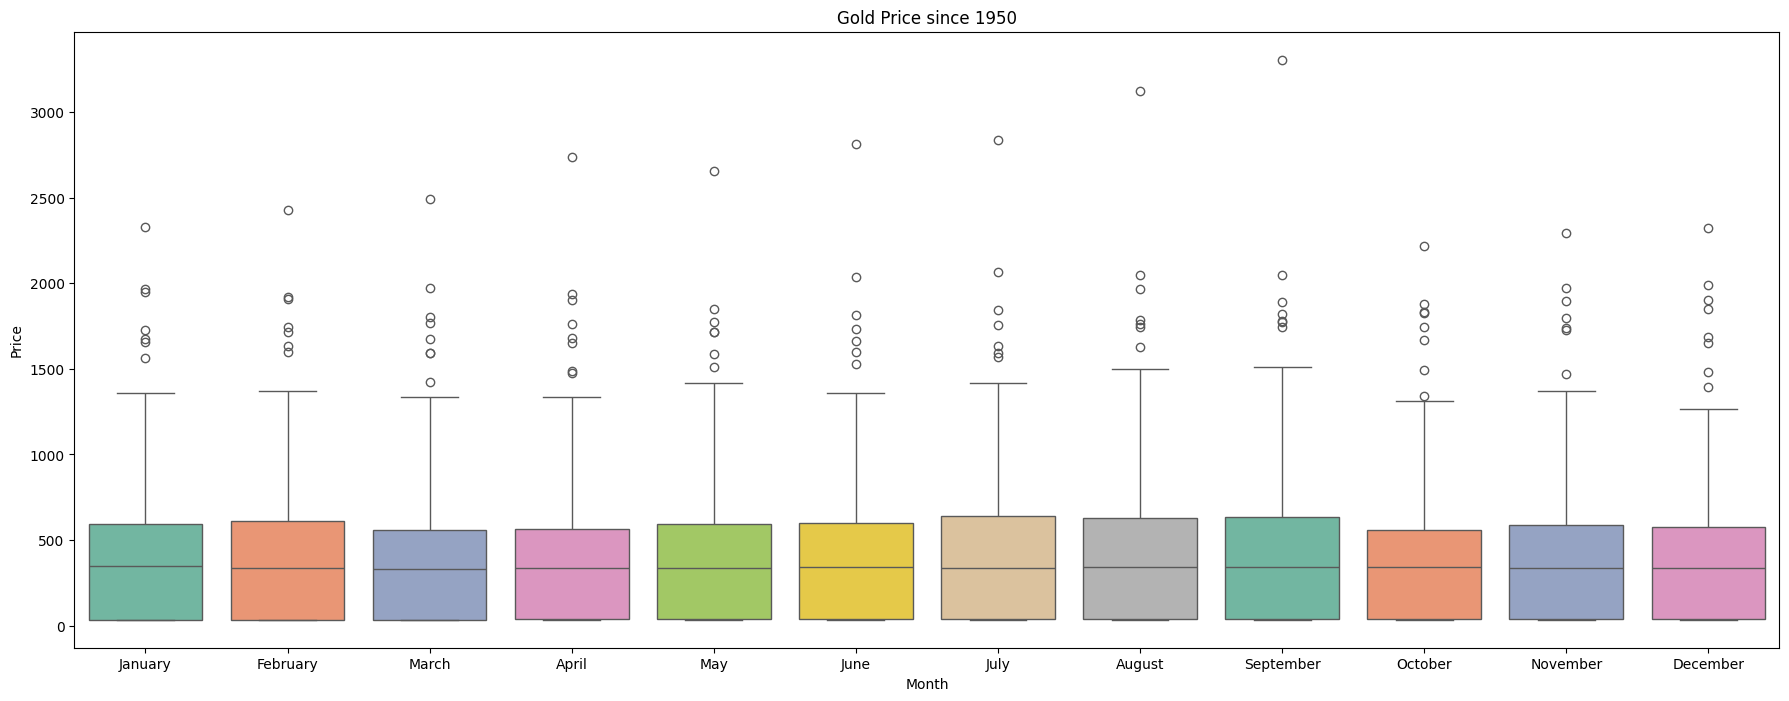

In [63]:
_, ax = plt.subplots(figsize = (22,8))
sns.boxplot(x = df.index.month_name(), y = df.values[:,0],ax = ax, palette = 'Set2')
plt.title('Gold Price since 1950')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show();
#The boxplot shows that the gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

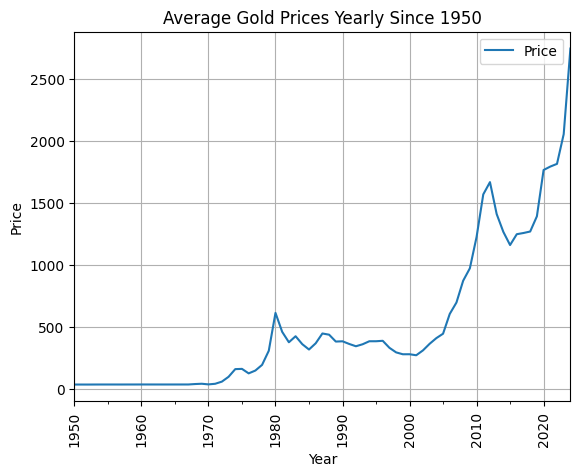

In [88]:
#Yearly Trend

df_yearly_sum = df.resample('A').mean() # A is for annual frequency, M is for monthly frequency, D is for daily frequency, H is for hourly frequency, T is for minutely frequency, S is for secondly frequency
df_yearly_sum.plot();
plt.title('Average Gold Prices Yearly Since 1950')
plt.xlabel('Year')
plt.ylabel('Price')
plt.xticks(rotation = 90)
plt.grid()
plt.show()
#The average gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

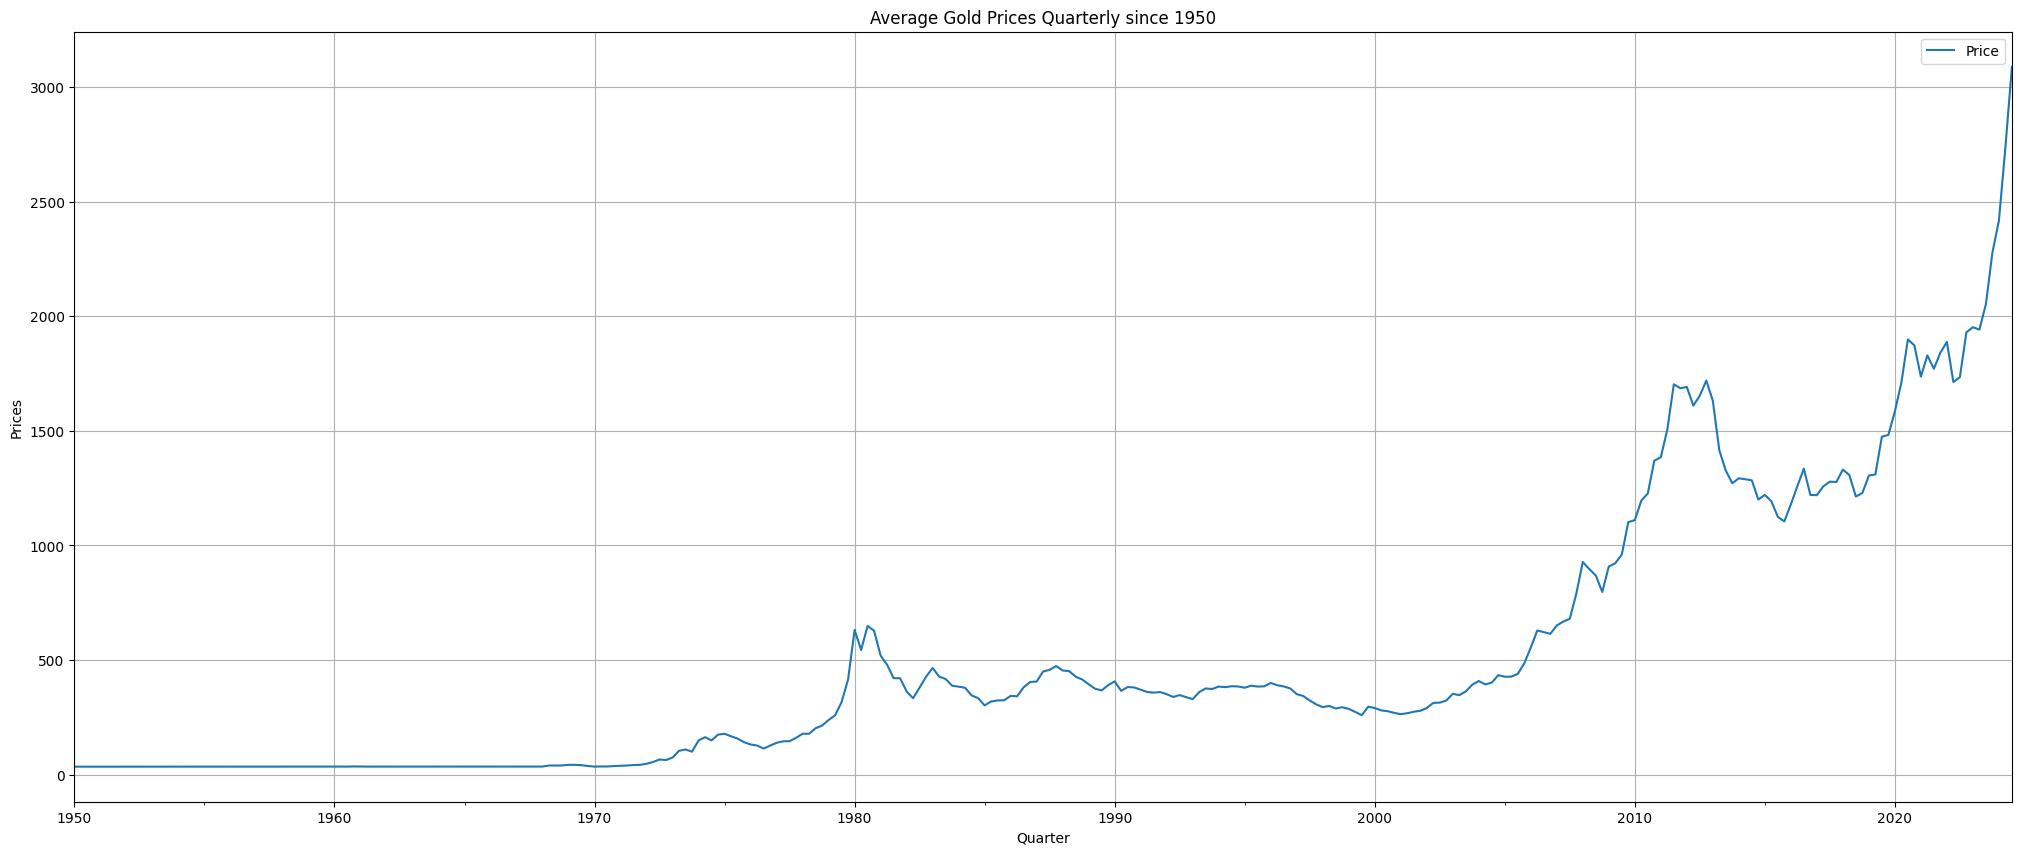

In [92]:
#Quarterly Trend

df_quarterly_sum = df.resample('Q').mean() # Q is for quarterly frequency
df_quarterly_sum.plot(figsize = (25,10))
plt.title("Average Gold Prices Quarterly since 1950")
plt.xlabel('Quarter')
plt.ylabel('Prices')
plt.grid()
plt.show()

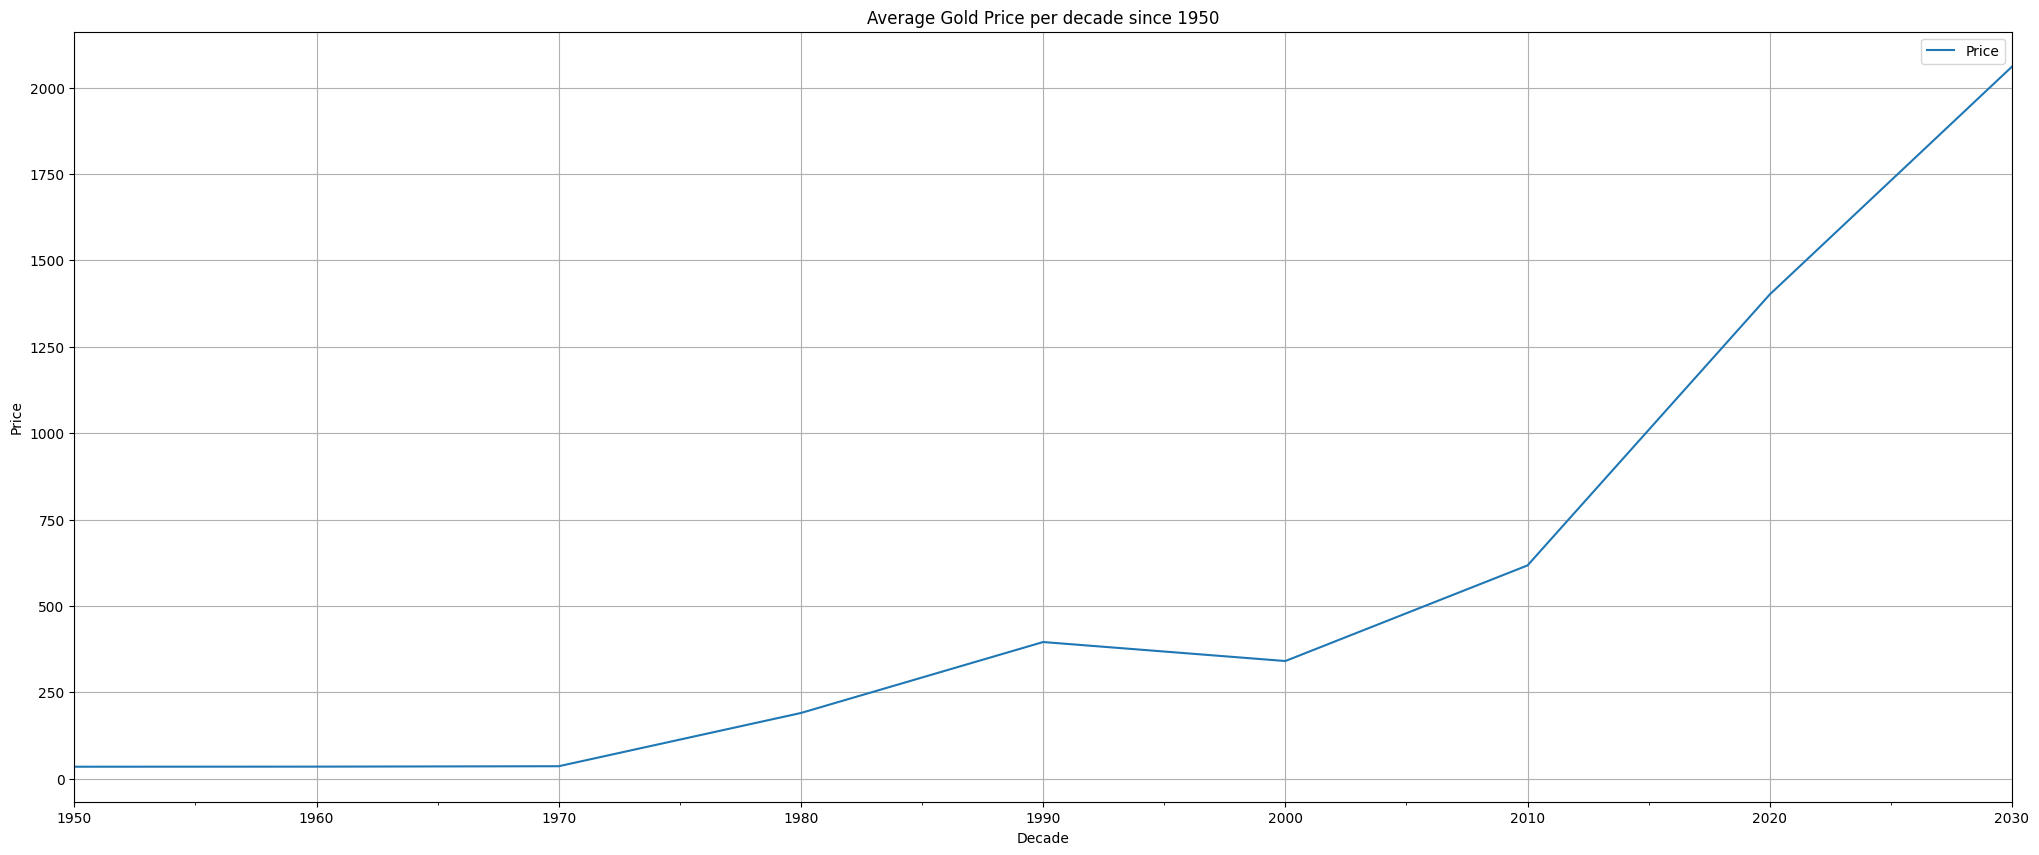

In [94]:
#Decade Trend

df_decade_sum = df.resample('10Y').mean() # 10Y is for decade frequency
df_decade_sum.plot(figsize = (25,10))
plt.title('Average Gold Price per decade since 1950')
plt.xlabel('Decade')
plt.ylabel('Price')
plt.grid()
plt.show()

In [99]:
# CV - Coefficient of Variation

df_1 = df.groupby(df.index.year).mean().rename(columns = {'Price' : 'Mean'}) #grouping the data by year and taking the mean of the prices
df_1 = df_1.merge(df.groupby(df.index.year).std().rename(columns = {'Price' : 'Std'}), left_index = True, right_index = True) #merging the mean and standard deviation dataframes
df_1['Cov_pct'] = ((df_1['Std']/df_1['Mean'])*100).round(2) #calculating the coefficient of variation

df_1.head() #displaying the first few rows of the dataframe

,Mean,Std,Cov_pct
month,,,
1950,34.729167,0.002887,0.01
1951,34.717500,0.020057,0.06
1952,34.628333,0.117538,0.34
1953,34.879167,0.056481,0.16
1954,35.020000,0.082792,0.24


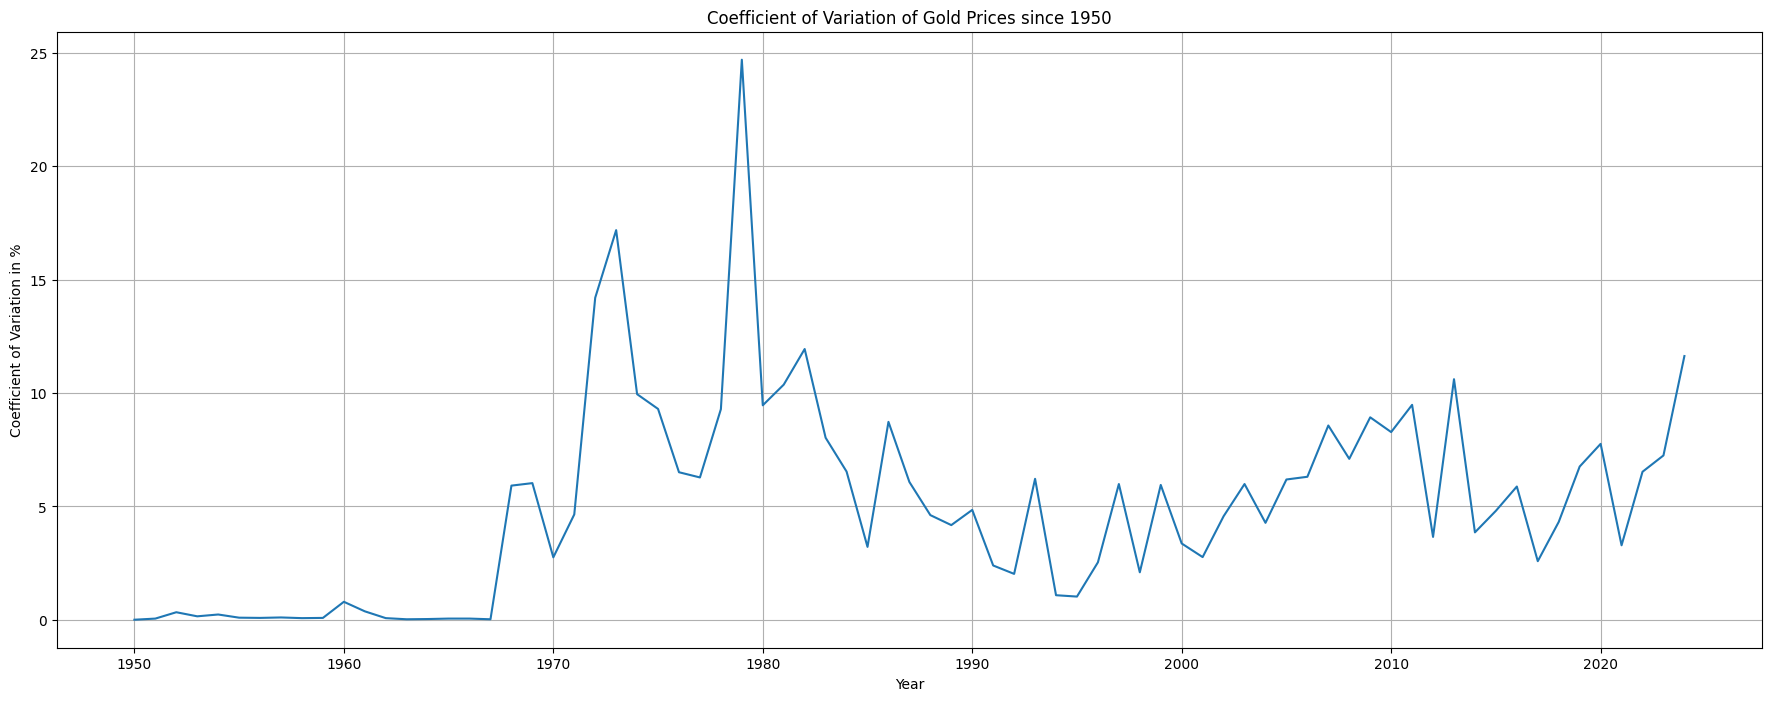

In [102]:
fig, ax = plt.subplots(figsize = (22 , 8)) #creating a figure and axis for the plot
df_1['Cov_pct'].plot(); #plotting the coefficient of variation
plt.title('Coefficient of Variation of Gold Prices since 1950') #setting the title of the plot
plt.xlabel('Year') #labeling the x-axis
plt.ylabel('Coefficient of Variation in %') #labeling the y-
plt.grid() #adding grid lines to the plot
plt.show() #showing the plot

**TIME SERIES FORECASTING MODELS**

In [111]:
train = df[df.index.year < 2019] #taking the data before 2015 as the training data
test = df[df.index.year >= 2019] #taking the data after 2015 as the test data

In [112]:
print(train.shape) #displaying the shape of the training data
print(test.shape) #displaying the shape of the test data

(828, 1)
(69, 1)


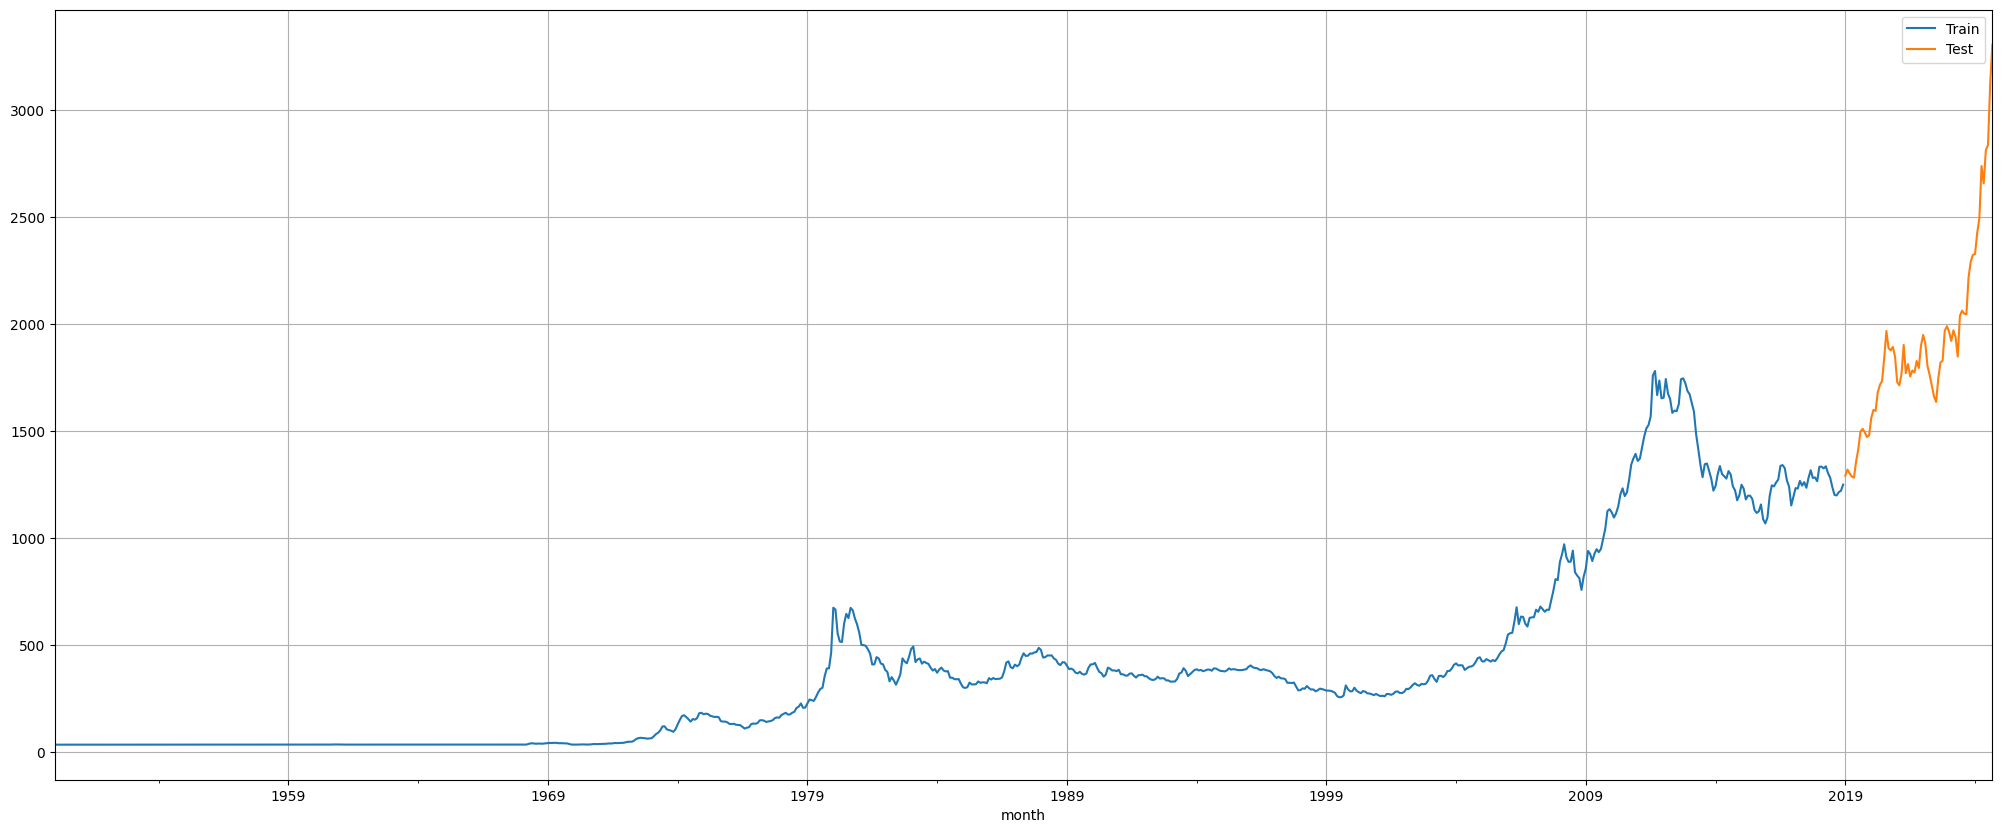

In [113]:
train['Price'].plot(figsize = (25,10)) #plotting the training data
test['Price'].plot(figsize = (25,10)) #plotting the test data
plt.grid() #adding grid lines to the plot
plt.legend(['Train', 'Test']) #adding legend to the plot
plt.show() #showing the plot

**LINEAR REGRESSION MODEL**

In [114]:
train_time = [i+1 for i in range(len(train))] #creating a list of time values for the training data
test_time = [i+len(train)+1 for i in range(len(test))] #creating a list of time values for the test data
len(train_time), len(test_time) #displaying the length of the time values for the training and test data

(828, 69)

In [115]:
LR_train = train.copy() #creating a copy of the training data for linear regression
LR_test = test.copy() #creating a copy of the test data for linear regression

In [117]:
LR_train['time'] = train_time #adding the time values to the training data
LR_test['time'] = test_time #adding the time values to the test data

In [118]:
lr = LinearRegression() #creating a linear regression model
lr.fit(LR_train[['time']], LR_train['Price']) #fitting the model to the training data

LinearRegression()

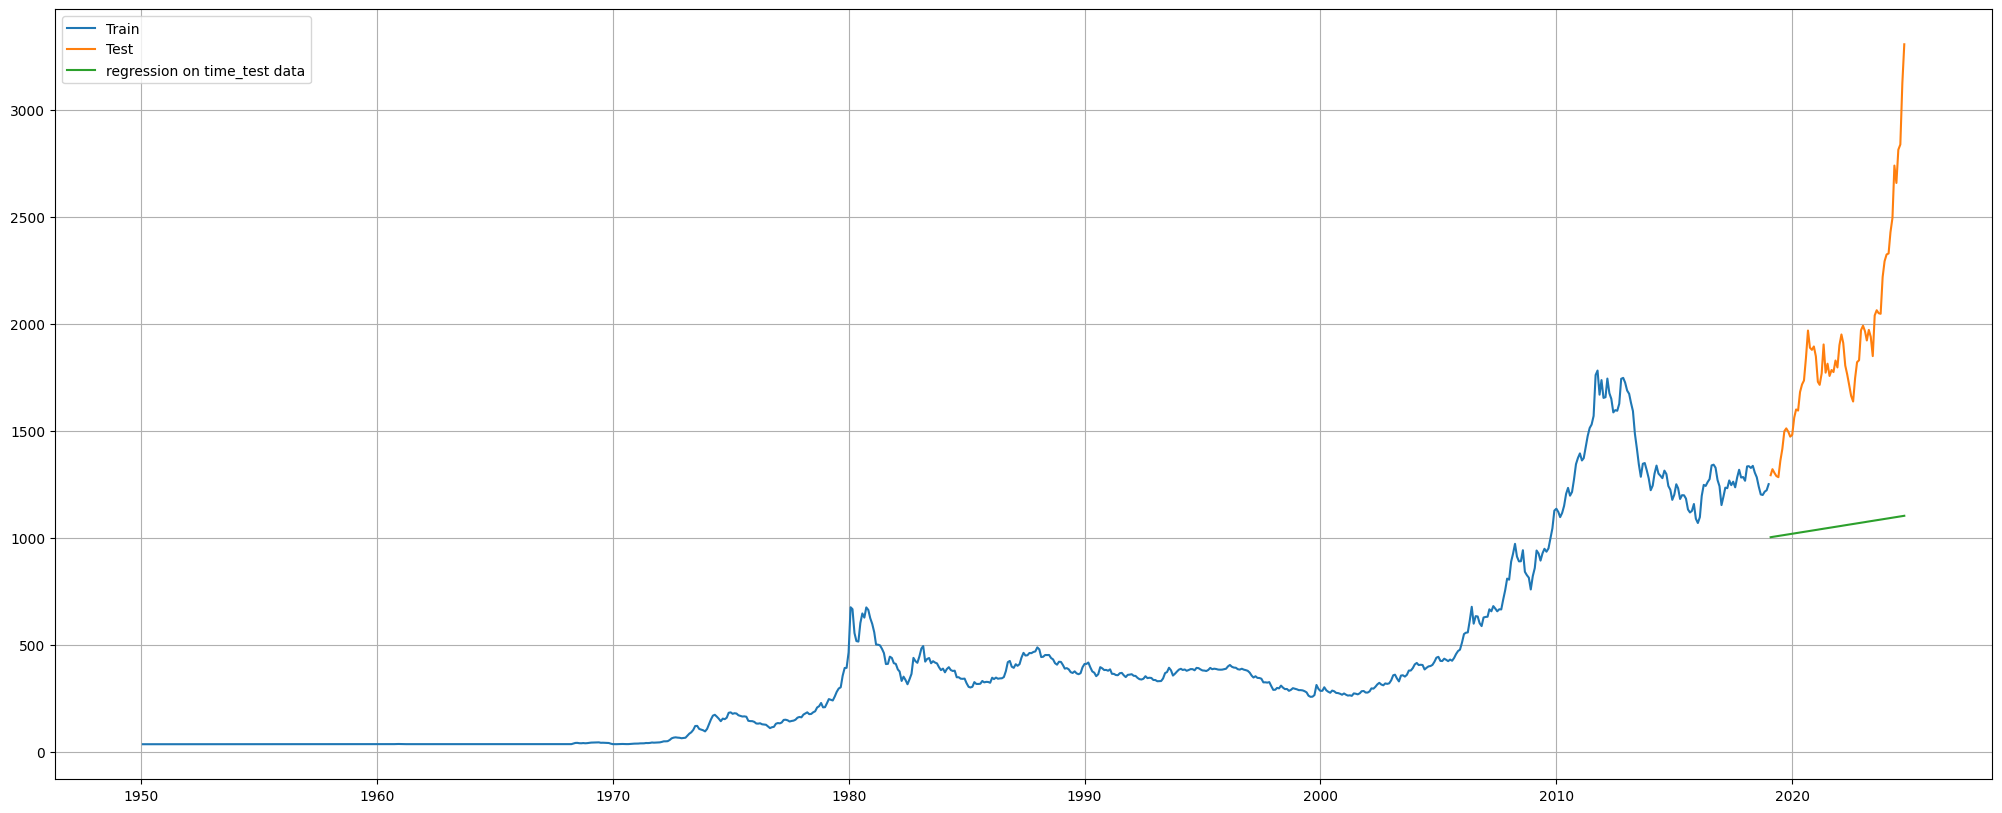

In [119]:
test_prediction_model1 = lr.predict(LR_test[['time']]) #predicting the test data using the model
LR_test['forecast'] = test_prediction_model1 #adding the predicted values to the test data

plt.figure(figsize = (25,10)) #creating a figure for the plot
plt.plot(train['Price'], label = 'Train') #plotting the training data
plt.plot(test['Price'], label = 'Test') #plotting the test data
plt.plot(LR_test['forecast'], label = 'regression on time_test data') #plotting the predicted values
plt.legend(loc = 'best') #adding legend to the plot
plt.grid() #adding grid lines to the plot
plt.show() #showing the plot

In [124]:
def mape(actual, predicted): #function to calculate the mean absolute percentage error
    return round(np.mean(np.abs((actual - predicted) / actual)) * 100, 2) #calculating the mean absolute percentage error

In [125]:
mape_model1_test = mape(test['Price'].values, test_prediction_model1) #calculating the mean absolute percentage error for the test data
print( "MAPE is %3.3f" %(mape_model1_test), "%") #displaying the mean absolute percentage error for the test 

#MAPE = Measure of Accuracy Percentage Error
#The MAPE value is 0.0% which means that the model is very accurate in predicting the test data. The model is able to predict the test data with 0.0% error.

MAPE is 42.360 %


In [127]:
results = pd.DataFrame({'Test MAPE (%)': [mape_model1_test]}, index = ["RegressionOnTime"]) #creating a dataframe to store the mean absolute percentage error values for the test data
results

,Test MAPE (%)
RegressionOnTime,42.36


**NAIVE BAYES MODEL**

In [128]:
Naive_train = train.copy() #creating a copy of the training data for naive model
Naive_test = test.copy() #creating a copy of the test data for naive model

In [130]:
Naive_test['naive'] = np.asarray(train['Price'])[len(np.asarray(train['Price']))-1] #adding the naive values to the test data
Naive_test['naive'].head() #displaying the first few rows of the test data with naive values

month
2019-01-31    1249.887
2019-02-28    1249.887
2019-03-31    1249.887
2019-04-30    1249.887
2019-05-31    1249.887
Name: naive, dtype: float64

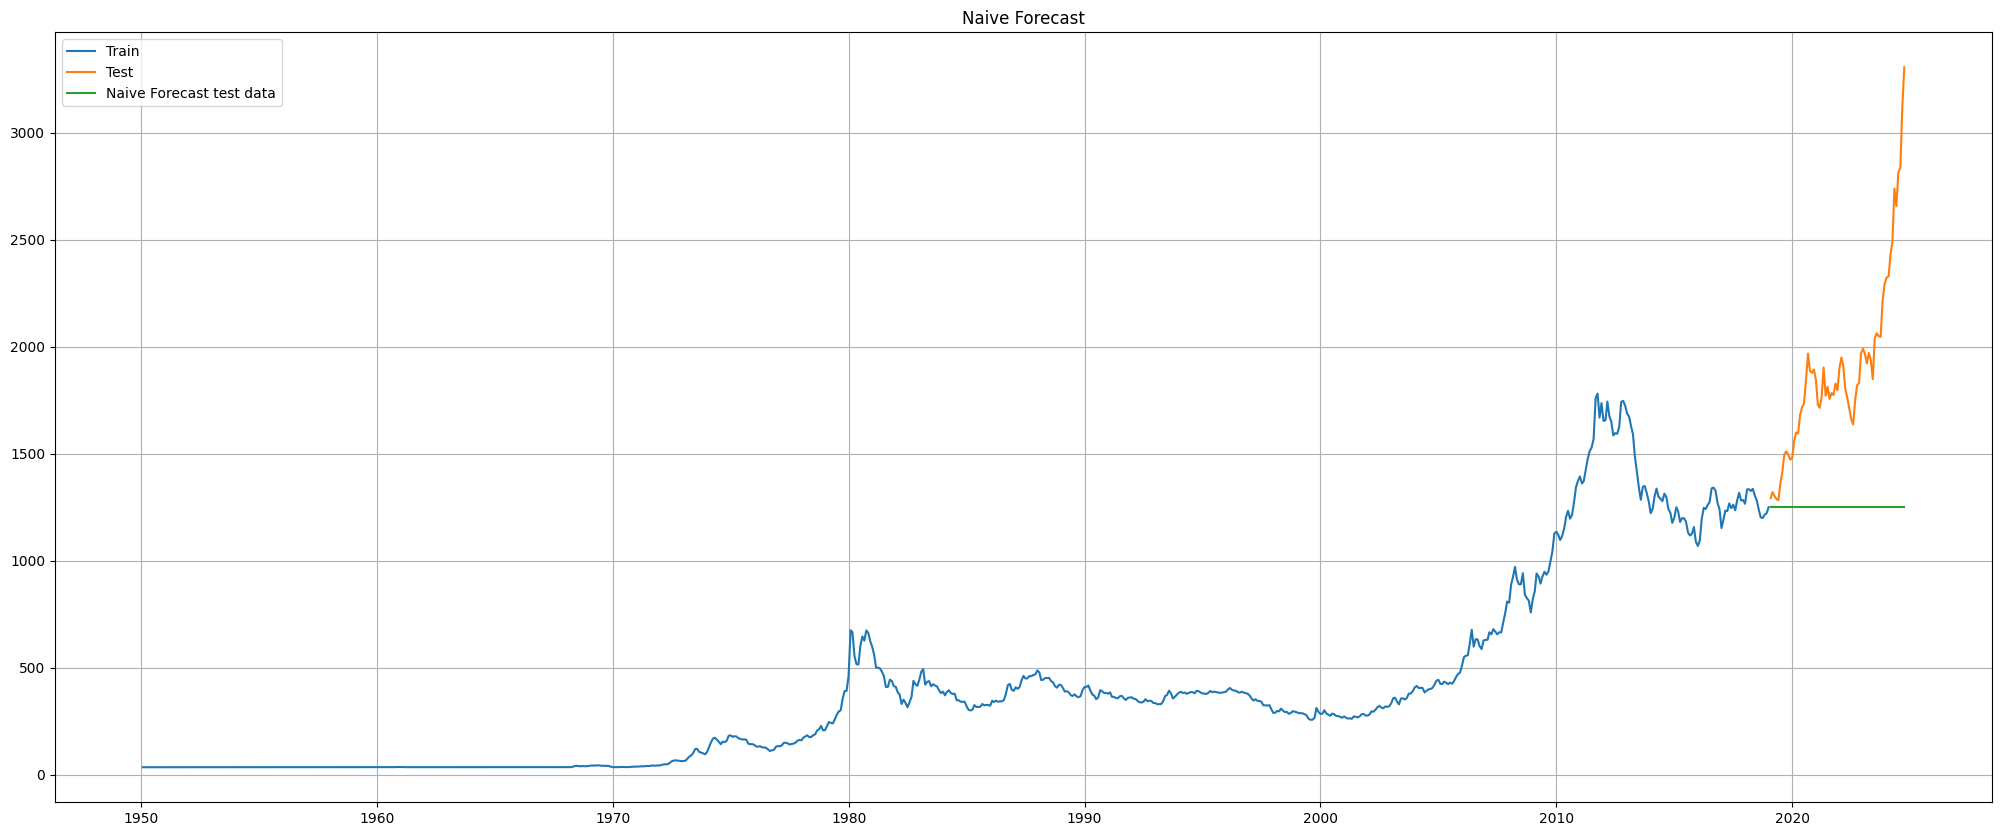

In [133]:
plt.figure(figsize = (25,10)) #creating a figure for the plot
plt.plot(Naive_train['Price'], label = 'Train') #plotting the training data
plt.plot(test['Price'], label = 'Test') #plotting the test 
plt.plot(Naive_test['naive'], label = 'Naive Forecast test data') #plotting the naive values
plt.legend(loc = 'best') #adding legend to the plot
plt.grid() #adding grid lines to the plot
plt.title('Naive Forecast') #setting the title of the plot
plt.show() #showing the plot

In [134]:
mape_model2_test = mape(test['Price'].values, Naive_test['naive'].values) #calculating the mean absolute percentage error for the test data with naive values
print( "For Naive Forecast on the test data, MAPE is %3.3f" %(mape_model2_test), "%") #displaying the mean absolute percentage error for the test data with naive values

For Naive Forecast on the test data, MAPE is 31.180 %


In [135]:
resultsDf_2 = pd.DataFrame({'Test MAPE (%)': [mape_model2_test]}, index = ["NaiveModel"]) #creating a dataframe to store the mean absolute percentage error values for the test data with naive values
results = pd.concat([results, resultsDf_2]) #concatenating the dataframes to store the mean absolute percentage error values for the test data with naive values

results #displaying the dataframe with the mean absolute percentage error values for the test data with naive values

,Test MAPE (%)
RegressionOnTime,42.36
NaiveModel,31.18


**FINAL MODEL / FINAL FORECASTING**

In [136]:
final_model = ExponentialSmoothing(df,
                                   trend = 'additive',
                                   seasonal= 'additive').fit(smoothing_level = 0.4,
                                                             smoothing_trend = 0.3,
                                                             smoothing_seasonal = 0.6)

In [137]:
Mape_final_model = mape(df['Price'].values, final_model.fittedvalues) #calculating the mean absolute percentage error for the final model
print("MAPE: ", Mape_final_model)

MAPE:  14.08


In [139]:
predictions = final_model.forecast(steps = len(test)) #predicting the values for the test data using the final model

In [141]:
pred_df = pd.DataFrame({'lower_CI' : predictions - 1.96 * np.std(final_model.resid,ddof = 1),
                        'upper_CI' : predictions + 1.96 * np.std(final_model.resid,ddof = 1),
                        'predictions' : predictions})

pred_df.head()

,lower_CI,upper_CI,predictions
2024-10-31,3470.262188,3742.866937,3606.564562
2024-11-30,3631.621373,3904.226122,3767.923748
2024-12-31,3707.940894,3980.545643,3844.243269
2025-01-31,3719.171894,3991.776643,3855.474269
2025-02-28,3755.412901,4028.017650,3891.715275


**FORECAST GRAPH**

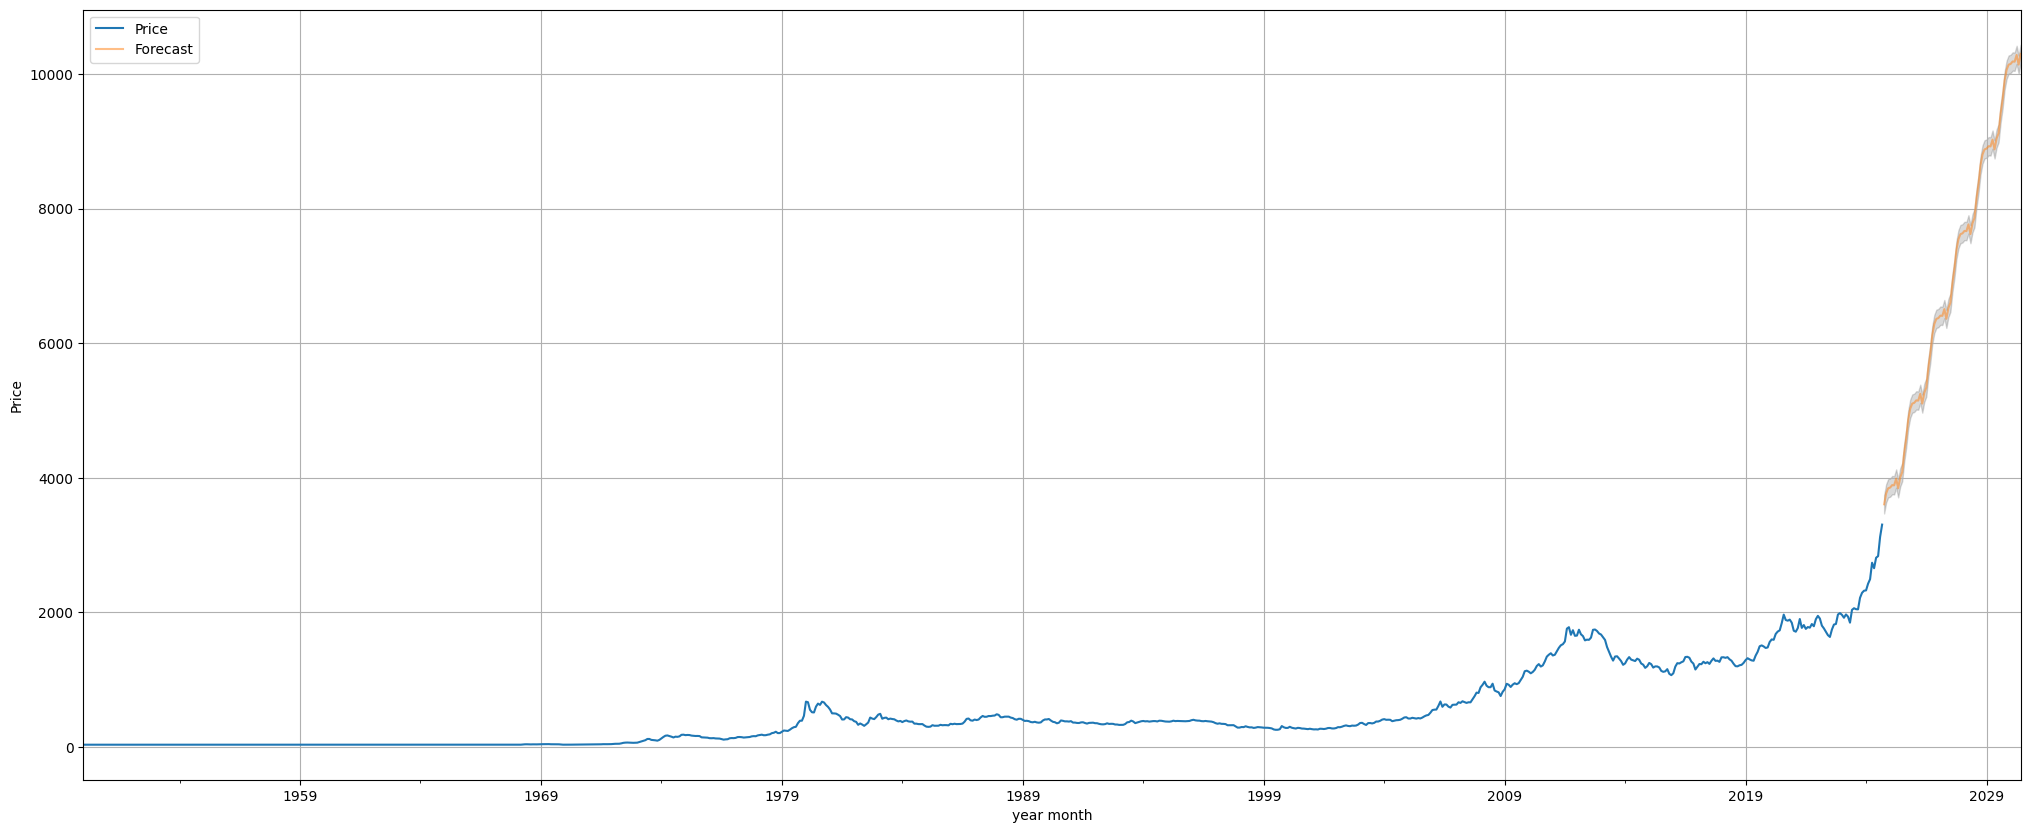

In [144]:
axis = df.plot(label = 'Actual', figsize = (25,10)) #creating a figure for the plot
pred_df['predictions'].plot(ax = axis, label = 'Forecast', alpha = 0.5) #plotting the predicted values
axis.fill_between(pred_df.index, pred_df['lower_CI'], pred_df['upper_CI'], color = 'k', alpha = 0.15) #filling the area between the lower and upper confidence intervals
axis.set_xlabel('year month') #labeling the x-
axis.set_ylabel('Price') #labeling the y-axis
plt.legend(loc = 'best') #adding legend to the plot
plt.grid()
plt.show() #showing the plot